## How to load trained model (NN Classifier)

Add neural network implementation to path

In [78]:
import os
import sys

# IMPORTANT: add NN_classifier to path
sys.path.append("NN_classifier")

Load trained model

In [79]:
import numpy as np
import pickle
from neural_network import NeuralNetworkClassifier

trained_model_dir = os.path.join("trained_models")
model_name = "NN_classifier_finetuned.pkl"
model_path = os.path.join(trained_model_dir, model_name)

with open(model_path, "rb") as f: 
    nn_classifier_model: NeuralNetworkClassifier = pickle.load(f)

print(len(nn_classifier_model.layers))
print([layer.shape for layer in nn_classifier_model.layers])

4
[(768, 512), (512, 512), (512, 512), (512, 10)]


Test that the model works

In [80]:
from NN_preprocessing import NN_preprocess_samples, load_samples
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Load and preprocess samples
samples, labels = load_samples("training_data")
X, y = NN_preprocess_samples(samples), np.array(labels)

# Extract a random test set
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# Test model performance
y_pred = nn_classifier_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model accuracy: {accuracy*100:.2f} %")

Model accuracy: 97.50 %


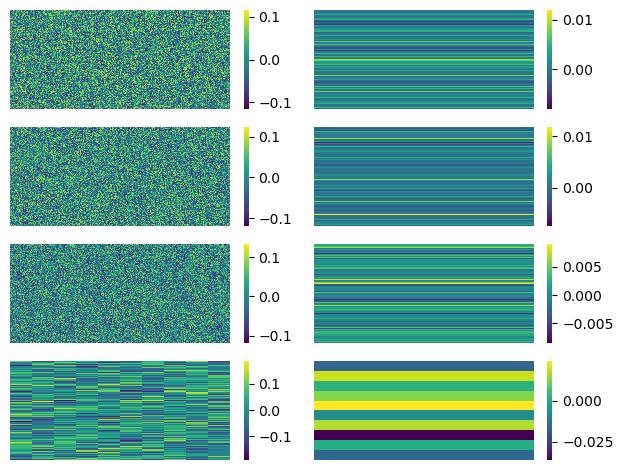

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

fix, axes = plt.subplots(len(nn_classifier_model.layers), 2)

for i, layer in enumerate(nn_classifier_model.layers):

    sns.heatmap(
        layer.weights,
        cmap="viridis", 
        ax=axes[i, 0], 
        annot=False,               # True if you want numbers
    )
    axes[i, 0].set_xticks([])
    axes[i, 0].set_yticks([])

    sns.heatmap(
        layer.biases.reshape(-1, 1),
        cmap="viridis", 
        ax=axes[i, 1], 
        annot=False,               # True if you want numbers
    )
    axes[i, 1].set_xticks([])
    axes[i, 1].set_yticks([])

plt.tight_layout()
plt.show()